In [68]:
# Ctrl + Shift + P > Format cell : formatear la celda. La identacion de los loops debe ser correcta
# Ctrl + J : Abrir terminal

"""
EXAMEN: 
    2 PARTES:
    - Primera parte 3 preguntas test (10-15 min) <- NO PODEMOS ACCEDER A LAS PRACTICAS
        # ex: en la clase scikitlearn, el parametro k sirve para...

    - Segunda parte experimento (resto (35 min)) <- PODEMOS ACCEDER A LAS PRACTICAS


"""

'\nEXAMEN: \n    2 PARTES:\n    - Primera parte 3 preguntas test (10-15 min) <- NO PODEMOS ACCEDER A LAS PRACTICAS\n        # ex: en la clase scikitlearn, el parametro k sirve para...\n\n    - Segunda parte experimento (resto (35 min)) <- PODEMOS ACCEDER A LAS PRACTICAS\n\n\n'

In [69]:
"""
PARA EL EXAMEN:
    SABER COMO FUNCIONA PCA: escoge la proyección lineal ortogonal W de mínima distorsión o error de reconstrucción
    SABER COMO FUNCIONA LOS METODOS fit(X), transform(x), fit_transform(x), inverse_transform(x)
        cunado creamos PCA, llamamos a fit(x) -> calcula matriz proyeción
                            leugo llamamos transform(x) -> reduciz a una proyecxion mas pequeña
                            fit_transfomr(x) hace ambas cosas al mismo tiemp
                            inverse_transform(x) -> devuelve a los k dimensiones originales
    SABER LOS DATASETS DE QUE SON:
        MNIST: numeros
        FASHION-MNIST: ropa
        ...
    SABER QUE ES EL ERROR DE RECONSTRUCCIÓN:
        En PCA, primero calculamos la proyección lineal ortogonal W que provoque el menor error al reducir las dimensiones de los datos originales
        El error se calcula como 1/N * ||X-hX||2F, que es la media de la suma al cuadrado de los elementos de la matriz X-hX, donde
        X son los datos originales y hX son los datos obtenidos después de la reconstruccion.
"""

'\nPARA EL EXAMEN:\n    SABER COMO FUNCIONA PCA: escoge la proyección lineal ortogonal W de mínima distorsión o error de reconstrucción\n    SABER COMO FUNCIONA LOS METODOS fit(X), transform(x), fit_transform(x), inverse_transform(x)\n        cunado creamos PCA, llamamos a fit(x) -> calcula matriz proyeción\n                            leugo llamamos transform(x) -> reduciz a una proyecxion mas pequeña\n                            fit_transfomr(x) hace ambas cosas al mismo tiemp\n                            inverse_transform(x) -> devuelve a los k dimensiones originales\n    SABER LOS DATASETS DE QUE SON:\n        MNIST: numeros\n        FASHION-MNIST: ropa\n        ...\n    SABER QUE ES EL ERROR DE RECONSTRUCCIÓN:\n        En PCA, primero calculamos la proyección lineal ortogonal W que provoque el menor error al reducir las dimensiones de los datos originales\n        El error se calcula como 1/N * ||X-hX||2F, que es la media de la suma al cuadrado de los elementos de la matriz X-hX, 

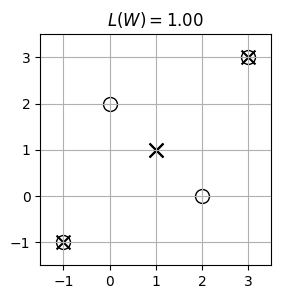

In [70]:
import numpy as np
import matplotlib.pyplot as plt

X = np.array([[-1, -1], [0, 2], [2, 0], [3, 3]])
N = len(X)
K = 1
# manual with numpy
_, _, Vt = np.linalg.svd(X - X.mean(0))
W = Vt[:K, :].T
Z = X @ W
hX = Z @ W.T
#
L = np.square(X - hX).sum(axis=1).mean()
fig, ax = plt.subplots(figsize=(3, 3))
ax.set_aspect("equal")
plt.axis([-1.5, 3.5, -1.5, 3.5])
plt.grid(True)
ax.set_title(f"$L(W)={L:.2f}$")
plt.scatter(*X.T, facecolor="white", edgecolor="k", s=100)
plt.scatter(*hX.T, facecolor="black", s=100, marker="x")

# N = 4 datos, D = 2. K = 1. Vamos a reducir a esa dimensión K para luego reconstruir la matriz a la dim D.
# Vt = calculada utilizando la descomposicion de valores singulares SVD. Calculamos W, matriz de proyección, cogiendo los k primeros vectores
# X-X.mean(0) ---> Centramos los datos respecto a un eje (0 -> columnas)
# Vt = np.linalg.svd(...)
# W = Vt[:K, :].T --> Vt está traspuesta. Si queremos los k primeros vecotres, debemos trasponer Vt y cogerlos.
# Z: matriz d datos proyectada a dimension K. La reconstruimos y nos da hX
# Z = X @ W --> Producto matriz
# Con ambas matrices calculamos la diferencia. El resultado lo volvemos a representar
# La diferencia la calculabamos como 1/N *||X - hX||2F, que es 1/N * suma de los elementos de la matriz X-hX al cuadrado
# np.square(X - hX).sum(axis=1).mean()
# Hemos perdido un poco de información al comprimirla y descomprimirla (hay 3 puntos, en vez de 4)

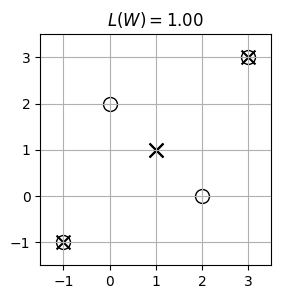

In [71]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA  # IMPORTAMOS PCA DESDE sklearn.

"""
Clase PCA:
    parametro n_components : dim K
    fit(x): calcula la proyeccion W
    transform(x): APLICA la proyeccion W sobre los datos X
    fit_transform(x): hace ambas cosas
    inverse_transform(x): reconstruye desde el espacio reducido
"""

X = np.array([[-1, -1], [0, 2], [2, 0], [3, 3]])
N = len(X)
K = 1
# sklearn
pca = PCA(n_components=K).fit(X - X.mean(0))
Z = pca.transform(X)
hX = pca.inverse_transform(Z)
#
L = np.square(X - hX).sum(axis=1).mean()
fig, ax = plt.subplots(figsize=(3, 3))
ax.set_aspect("equal")
plt.axis([-1.5, 3.5, -1.5, 3.5])
plt.grid(True)
ax.set_title(f"$L(W)={L:.2f}$")
plt.scatter(*X.T, facecolor="white", edgecolor="k", s=100)
plt.scatter(*hX.T, facecolor="black", s=100, marker="x")

# importamos PCA desde sklearn. Lo utilizamos llamandolo pasando las dimensiones.
#   W = PCA(n_components = K).fit(X-X.mean(0)) --> centramos los datos y utilizamos la funcion de sklearn PCA para conseguir la proyeccion ortogonal de min distorsión
#   fit(...) --> calcula la proyeccion ortogonal de min dist.

# Este ejemplo nos muestra que podemos rabajar con sklearn, que funciona igual y nos facilitara la vida
# fit: caclula la matriz de proyeccion
# transform: proyecta la matriz

SVDResult(U=array([[-0.17149859,  0.5       , -0.17751222,  0.83010701],
       [-0.68599434, -0.5       ,  0.46130531,  0.25808754],
       [ 0.17149859,  0.5       ,  0.84459583, -0.08512415],
       [ 0.68599434, -0.5       ,  0.2057783 ,  0.48689532]]), S=array([4.12310563, 0.70710678]), Vh=array([[ 0.70710678, -0.70710678],
       [ 0.70710678,  0.70710678]]))


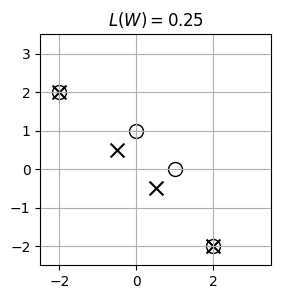

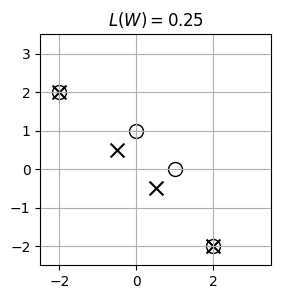

In [72]:
import numpy as np
import matplotlib.pyplot as plt
# En el primer ejemplo acaba aqui. En el segundo ejemplo importa sklearn
from sklearn.decomposition import PCA

X = np.array([[0, 1], [-2, 2], [1, 0], [2, -2]])
N = len(X)
K = 1

# Si solo utilizara numpy
print(np.linalg.svd(X - X.mean(0)))
_, _, Vt = np.linalg.svd(X - X.mean(0))   # Vt. Los k primeros vectores de V son W
# np.linalg.svd devuelve las matrices USVt en una tupla. Al poner la expresion _, _, Vt, descartamos U y S, y nos quedamos con Vt
W = Vt[:K, :].T
Z = X @ W
hX = Z @ W.T

L = np.square(X-hX).sum(axis=1).mean()
fig, ax = plt.subplots(figsize=(3, 3))
ax.set_aspect("equal")
plt.axis([-2.5, 3.5, -2.5, 3.5])
plt.grid(True)
ax.set_title(f"$L(W)={L:.2f}$")
plt.scatter(*X.T, facecolor="white", edgecolor="k", s=100)
plt.scatter(*hX.T, facecolor="black", s=100, marker="x")

# Si utilizara Sklearn:
W = PCA(n_components=K).fit(X-X.mean(0))
Z = W.transform(X)
hX = W.inverse_transform(Z)

L = np.square(X-hX).sum(axis=1).mean()
fig, ax = plt.subplots(figsize=(3, 3))
ax.set_aspect("equal")
plt.axis([-2.5, 3.5, -2.5, 3.5])
plt.grid(True)
ax.set_title(f"$L(W)={L:.2f}$")
plt.scatter(*X.T, facecolor="white", edgecolor="k", s=100)
plt.scatter(*hX.T, facecolor="black", s=100, marker="x")



<br>


# MNIST

In [ ]:
#   
import numpy as np; import datasets
ds = datasets.load_dataset("ylecun/mnist").with_format("numpy"); ds


DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 60000
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 10000
    })
})

In [74]:
train0 = ds["train"][0]
train0["image"].shape, train0["image"].dtype, train0["label"]

((28, 28), dtype('uint8'), np.int64(5))

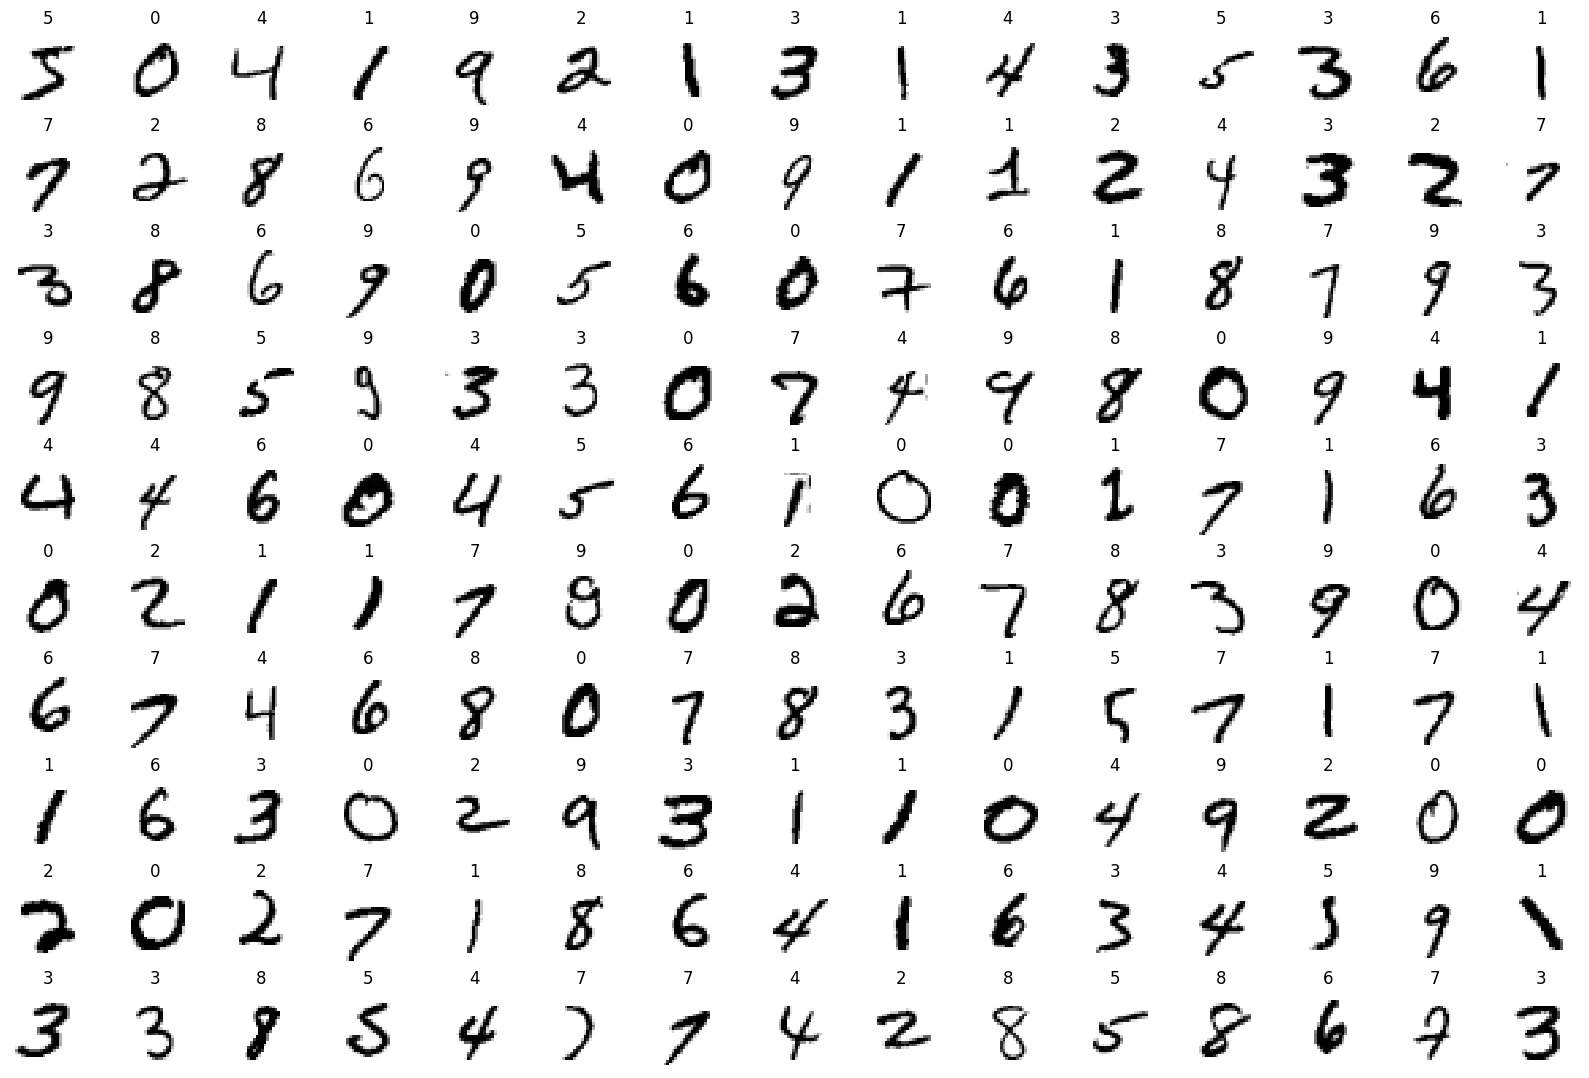

In [75]:
import matplotlib.pyplot as plt

nrows = 10
ncols = 15
N = nrows * ncols
_, axs = plt.subplots(
    nrows=nrows, ncols=ncols, figsize=(16, 16 * nrows / ncols), constrained_layout=True
)
for ax, x, y in zip(axs.flat, ds["train"][:N]["image"], ds["train"][:N]["label"]):
    ax.set_axis_off()
    ax.imshow(x, cmap=plt.cm.gray_r, interpolation="none")
    ax.set_title(y)

In [76]:
# PCA  aplicado a MNIST: estudio del error de reconstruccion en funcion de K
"""
PCA:Principal Component Analysis.
Se utiliza para reducir el error de reconstrucción
Dada una matriz de N(nº filas) datos de D dimensión (nº columnas), se reduce D a una dimensión K. Esta reducción es la codificación
Luego reconstruímos la matriz utilizando una matriz W: Z = XW    X' = XWt
Utilizando PCA obetenemos W tal que reduzca el error
"""

import numpy as np
import datasets

ds = datasets.load_dataset("ylecun/mnist").with_format("numpy")
X_train = ds["train"][:]["image"].astype(np.float32).reshape(-1, 28 * 28) / 255.0   
y_train = ds["train"][:]["label"].astype(np.uint8)
X_test = ds["test"][:]["image"].astype(np.float32).reshape(-1, 28 * 28) / 255.0
y_test = ds["test"][:]["label"].astype(np.uint8)

# X_train: samples de entrenamiento
# Y_train: clases de entrenamiento
# X-test: samples de test
# Y_test: clases de test

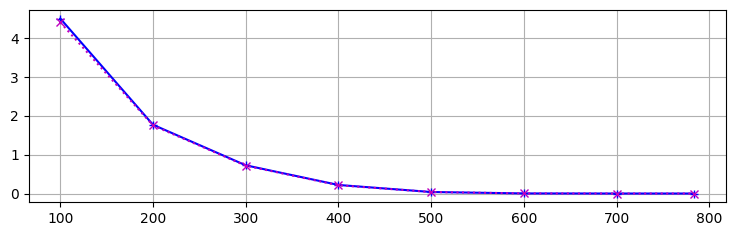

In [77]:

import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

max_K = np.min(X_train.shape)
#sklearn
pca = PCA(n_components=max_K).fit(X_train) # sklearn centra de manera manual. Antes centrabamos manualmente por la explicacion teorica, pero no se hace así realmente en la practica
Z_train = pca.transform(X_train)    # Obtiene los vectores reducidos Z
Z_test = pca.transform(X_test)
Ks = np.array([100, 200, 300, 400, 500, 600, 700, max_K])    # max_K
L_train = np.empty_like(Ks, dtype=float)
L_test = np.empty_like(Ks, dtype=float)
for i, K in enumerate(Ks): # enumerate(Ks) [(1,100), (2,200), (3,300)...]
    Z_train_K = Z_train.copy()  # copiamos en Z_train_K los vectores de Z_train
    Z_train_K[:, K:] = 0.0      # anulamos los componentes a partir de K. Solo convervamos las primeras K direcciones principales 
    hX_train = pca.inverse_transform(Z_train_K)                     # inverse_transform reconstruye los datos comprimidos en la imagen original, con cierto error que queremos reducir
    L_train[i] = np.square(X_train - hX_train).sum(axis=1).mean()   # calcula el error de reconstruccion y lo guarda en L_train[i]
    #Hace lo mismo con test
    Z_test_K = Z_test.copy()
    Z_test_K[:, K:] = 0.0
    hX_test = pca.inverse_transform(Z_test_K)
    L_test[i] = np.square(X_test - hX_test).sum(axis=1).mean()
plt.figure(figsize=(9, 2.5))
plt.grid(True)
plt.plot(Ks, L_train, "+-b", Ks, L_test, "x:m")

# La grafica resultante dice que. al teneer 774 dimensiones, conforme vamos reduciendo las dimensiones el error / diferencia entre
# la compresión y la matriz original va a ser mayor. Es decir, utilizar sobre 500 de dimension para
# conseguir un buen procesamiento y un buen coste. Más dimensinoes no mejoraría el procesameinto y costaróa mas
# y menos dimensiones daria más error

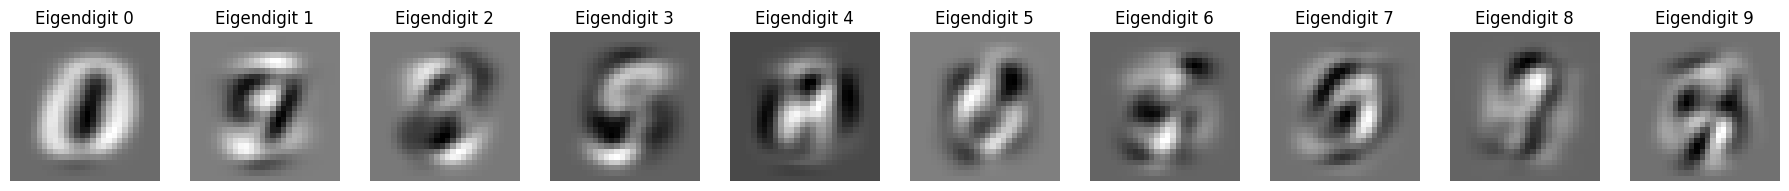

In [78]:
# Eigendigits y reconstruccion con dimension K

K = 400 # fija cual es la dimension reducida que queremos conservar. En este caso, 400 
pca = PCA(n_components=K).fit(X_train) # ajusta el modelo PCA: aprende la media y los componentes principales de X_train
nrows, ncols = 1, 10
fig, axs = plt.subplots(      # Crea una figura con 10 subplots en una fila para mostrar 10 imágenes
    nrows=nrows, ncols=ncols, figsize=(18, 18 * nrows / ncols), constrained_layout=True
)
for i in range(min(K, nrows * ncols)):
    ax = axs.flat[i]
    ax.set_axis_off()
    ax.set_title(f"Eigendigit {i}")
    ax.imshow(
        pca.components_[i, :].reshape((28, 28)), cmap=plt.cm.gray, interpolation="none" # reshape representa el vector de componentes principales en imagenes para ver el patron que representa cada eigendigit
    )

# Cada eigendigit no es un dígito, sino una "base" o dirección que el PCA ha aprendido. Combinando dichas bases se puede aproczimar iamgenes reales
# cada vector propcio se especializa en detectar unas caracterisitcas concretas. El Eigendigit 0 se especializa en detectar 0s, por ejemplo (blanco = mas importante)


# Los eigenvectors son reinterpretados como imagenes utilizando reshape. Estos eigenvectors son las columnas de V / las filas de Vt
# que ha sido calculada en el proceso de calcular W (o como la llama aquí, pca). Como W son los K primeros vectores de V, hacemos
# pca.components_[i, :].reshape((28,28))

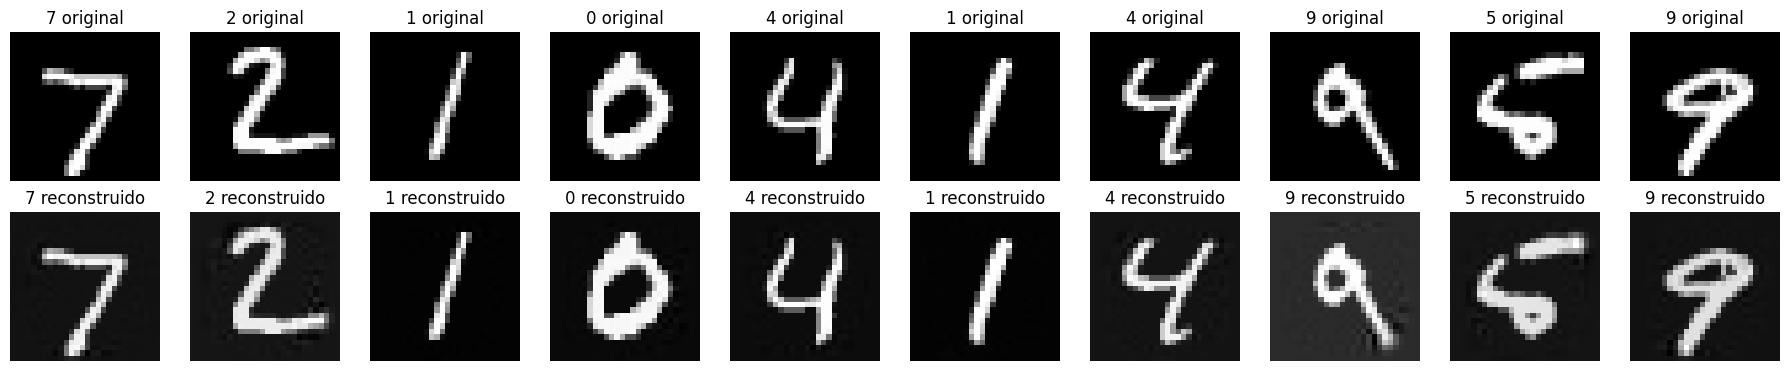

In [79]:
ncols = 10
Z_test = pca.transform(X_test[:ncols])
hX_test = pca.inverse_transform(Z_test)
fig, axs = plt.subplots(
    nrows=2, ncols=10, figsize=(18, 18 * 2 / ncols), constrained_layout=True
)
for i in range(ncols):
    ax = axs.flat[i]
    ax.set_axis_off()
    ax.set_title(f"{y_test[i]} original")
    ax.imshow(X_test[i, :].reshape((28, 28)), cmap=plt.cm.gray, interpolation="none")
    ax = axs.flat[ncols + i]
    ax.set_axis_off()
    ax.set_title(f"{y_test[i]} reconstruido")
    ax.imshow(hX_test[i, :].reshape((28, 28)), cmap=plt.cm.gray, interpolation="none")

# Al utilizar PCA hemos obtenido una matriz W que, tras usarla para reconstruir los datos originales nos ha permitido mantener
# la información original sin mucho error

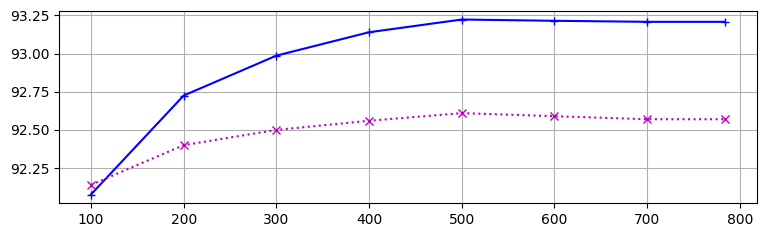

In [80]:
# precision de regresion logistica: modelo de clasificación de datos en clases
# Cuantas componentes principales K necesito para que un clasificador funcione bien?
from sklearn.linear_model import LogisticRegression

max_K = np.min(X_train.shape)
pca = PCA(n_components=max_K).fit(X_train) # W, obtienes la proyeccion ortogonal de minima distorsión (dim max_K)
Z_train = pca.transform(X_train)    # Z = X*W
Z_test = pca.transform(X_test)
Ks = np.array([100, 200, 300, 400, 500, 600, 700, max_K]) # en cada iteración comprobaremos K componentes principales
acc_train = np.empty_like(Ks, dtype=float)
acc_test = np.empty_like(Ks, dtype=float)
for i, K in enumerate(Ks):
    clf = LogisticRegression(C=0.1, max_iter=200).fit(Z_train[:, :K], y_train) # entrena utilizando solo las K primeras componentes (las K primeras columnas)
    acc_train[i] = clf.score(Z_train[:, :K], y_train)       # Nos guardamos su precisión
    acc_test[i] = clf.score(Z_test[:, :K], y_test)
plt.figure(figsize=(9, 2.5))
plt.grid(True)
plt.plot(Ks, 100.0 * acc_train, "+-b", Ks, 100.0 * acc_test, "x:m") # Train: azul     Test: magenta

# El maximo esta en 500, no en 800. Esto es debido al SOBREENTRENAMIENTO: el modelo se abruma
#
# X(numero de componentes K)   Y(precision) 
# Al aumentar K, la precisión aumenta al dar más informacion al modelo, pero hasta cierto punto

# PCA, al ordenar en W los eigenvectors de más importante (mayor) a menos importante(menor), ordena las características por importancia. Por
# esta razón, a partir de K características, la inclusión de más parámetros se vuelve redundante, y se sobreentrena / abruma al modelo, 
# empeorando su clasificación.

<br>


# Fashion-MNIST

In [81]:
# Ahora aplicaremos PCA a Fashion-MNIST
# Hay que comprobar que el error nulo llega con K >= 600

import numpy as np; import datasets
ds = datasets.load_dataset("zalando-datasets/fashion_mnist").with_format("numpy"); ds

DatasetDict({
    train: Dataset({
        features: ['image', 'label'],
        num_rows: 60000
    })
    test: Dataset({
        features: ['image', 'label'],
        num_rows: 10000
    })
})

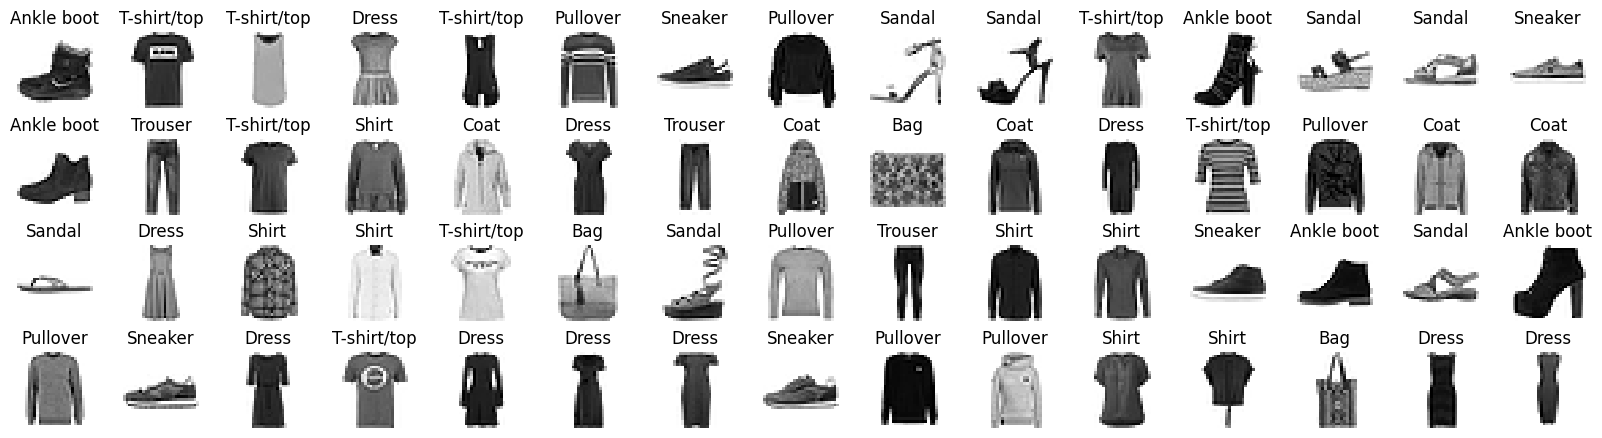

In [82]:
import matplotlib.pyplot as plt

nrows = 4
ncols = 15
N = nrows * ncols
labels = (
    "T-shirt/top",
    "Trouser",
    "Pullover",
    "Dress",
    "Coat",
    "Sandal",
    "Shirt",
    "Sneaker",
    "Bag",
    "Ankle boot",
)
_, axs = plt.subplots(
    nrows=nrows, ncols=ncols, figsize=(16, 16 * nrows / ncols), constrained_layout=True
)
for ax, x, y in zip(axs.flat, ds["train"][:N]["image"], ds["train"][:N]["label"]):
    ax.set_axis_off()
    ax.imshow(x, cmap=plt.cm.gray_r, interpolation="none")
    ax.set_title(labels[y])

In [83]:
import numpy as np
import datasets

ds = datasets.load_dataset("zalando-datasets/fashion_mnist").with_format(
    "numpy"
)  # descarga la base de datos y configura su salida en arrays NumPy
ds
# tomamos todas las imagenes de entrenamiento, pasandolas a float32, aplanándolas a un vector de 784 valores por imagen y normalizando los pixeles (0<->1)
X_train = ds["train"][:]["image"].astype(np.float32).reshape(-1, 28 * 28) / 255.0
y_train = ds["train"][:]["label"].astype(
    np.uint8
)  # comprime las etiquetas de entrenamiento y las convierte a enteross pequeños
X_test = ds["test"][:]["image"].astype(np.float32).reshape(-1, 28 * 28) / 255.0
y_test = ds["test"][:]["label"].astype(np.uint8)

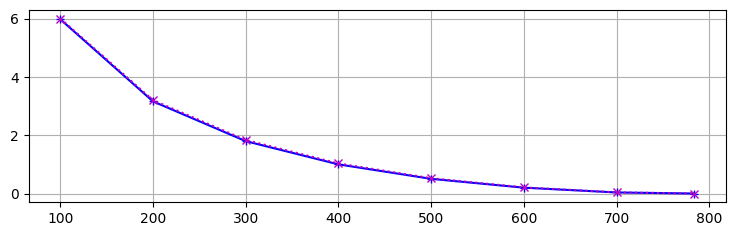

In [84]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

max_K = np.min(X_train.shape)
pca = PCA(n_components=max_K).fit(X_train)
Z_train = pca.transform(X_train)
Z_test = pca.transform(X_test)
Ks = np.array([100, 200, 300, 400, 500, 600, 700, max_K])
L_train = np.empty_like(Ks, dtype=float)
L_test = np.empty_like(Ks, dtype=float)
for i, K in enumerate(Ks):
    Z_train_K = Z_train.copy()
    Z_train_K[:, K:] = 0.0
    hX_train = pca.inverse_transform(Z_train_K)
    L_train[i] = np.square(X_train - hX_train).sum(axis=1).mean()
    Z_test_K = Z_test.copy()
    Z_test_K[:, K:] = 0.0
    hX_test = pca.inverse_transform(Z_test_K)
    L_test[i] = np.square(X_test - hX_test).sum(axis=1).mean()
plt.figure(figsize=(9, 2.5))
plt.grid(True)
plt.plot(Ks, L_train, "+-b", Ks, L_test, "x:m")

# Al llegar a K = 600 sí que el error se aproxima a 0

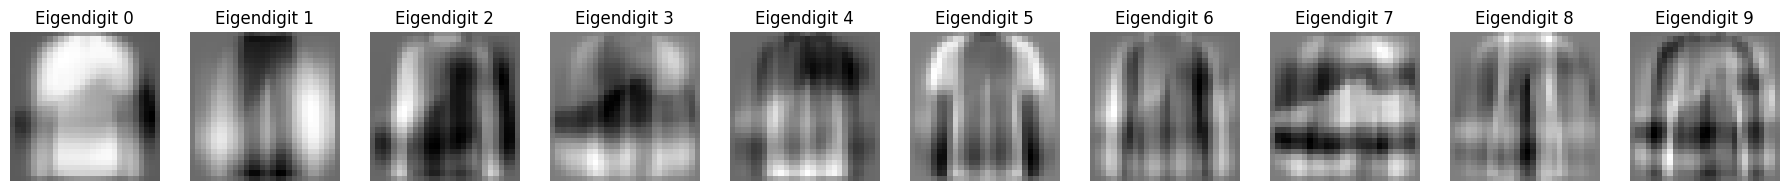

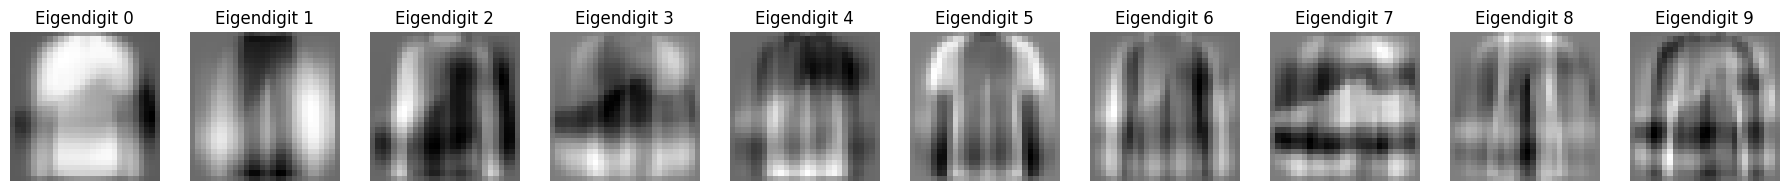

In [85]:

# CON K = 100
K = 100
pca = PCA(n_components=K).fit(X_train)
nrows, ncols = 1, 10
fig, axs = plt.subplots(
    nrows=nrows, ncols=ncols, figsize=(18, 18 * nrows / ncols), constrained_layout=True
)
for i in range(min(K, nrows * ncols)):
    ax = axs.flat[i]
    ax.set_axis_off()
    ax.set_title(f"Eigendigit {i}")
    ax.imshow(
        pca.components_[i, :].reshape((28, 28)), cmap=plt.cm.gray, interpolation="none"
    )


# CON K = 600
K = 600
pca = PCA(n_components=K).fit(X_train)
nrows, ncols = 1, 10
fig, axs = plt.subplots(
    nrows=nrows, ncols=ncols, figsize=(18, 18 * nrows / ncols), constrained_layout=True
)
for i in range(min(K, nrows * ncols)):
    ax = axs.flat[i]
    ax.set_axis_off()
    ax.set_title(f"Eigendigit {i}")
    ax.imshow(
        pca.components_[i, :].reshape((28, 28)), cmap=plt.cm.gray, interpolation="none"
    )

    

# arriba con K = 100 y abajo con K = 600. SOLO ESTAMOS MOSTRANDO LOS PRIMERSOS 10 COMPONENTES, que son los mismos para ambos casos. 
# NO OBSTANTE, EN K=600 ESTAMOS UTILIZANDO 500 COMPONENTES MÁS QUE NOS AYUDAN A COMPRIMIR MEJOR LAS IMAGENES SIN 
# PERDER INFORMACION

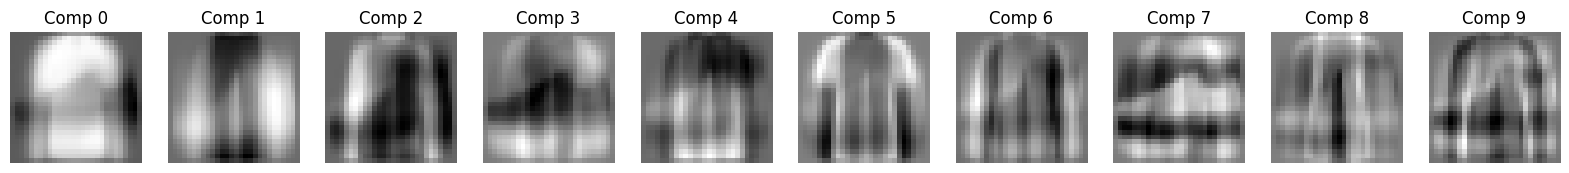

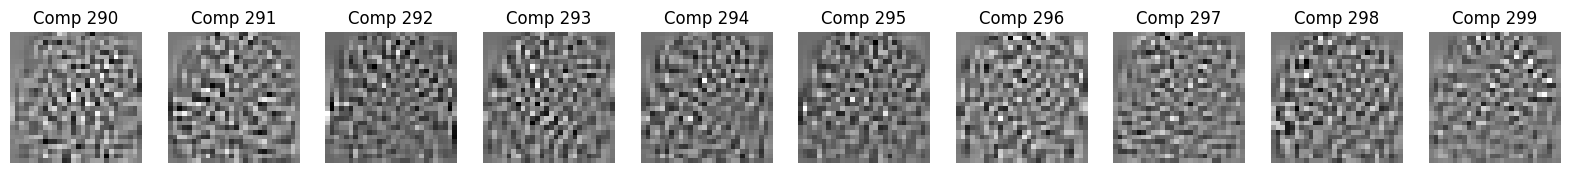

In [86]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
# EJEMPLO PARA MOSTRAR DISTINTOS COMPONENNTES   
# Entrenamos PCA con muchos componentes
K = 600
pca = PCA(n_components=K).fit(X_train)

# Rango de componentes que quieres visualizar
start = 0
end = 10   # muestra componentes 50 a 59

n = end - start
fig, axs = plt.subplots(1, n, figsize=(2*n, 2))

for idx, comp in enumerate(range(start, end)):
    ax = axs[idx]
    ax.set_axis_off()
    ax.set_title(f"Comp {comp}")
    ax.imshow(
        pca.components_[comp].reshape(28, 28),
        cmap="gray",
        interpolation="none"
    )

# Rango de componentes que quieres visualizar
start = 290
end = 300   # muestra componentes 50 a 59

n = end - start
fig, axs = plt.subplots(1, n, figsize=(2*n, 2))

for idx, comp in enumerate(range(start, end)):
    ax = axs[idx]
    ax.set_axis_off()
    ax.set_title(f"Comp {comp}")
    ax.imshow(
        pca.components_[comp].reshape(28, 28),
        cmap="gray",
        interpolation="none"
    )

(10000, 784)


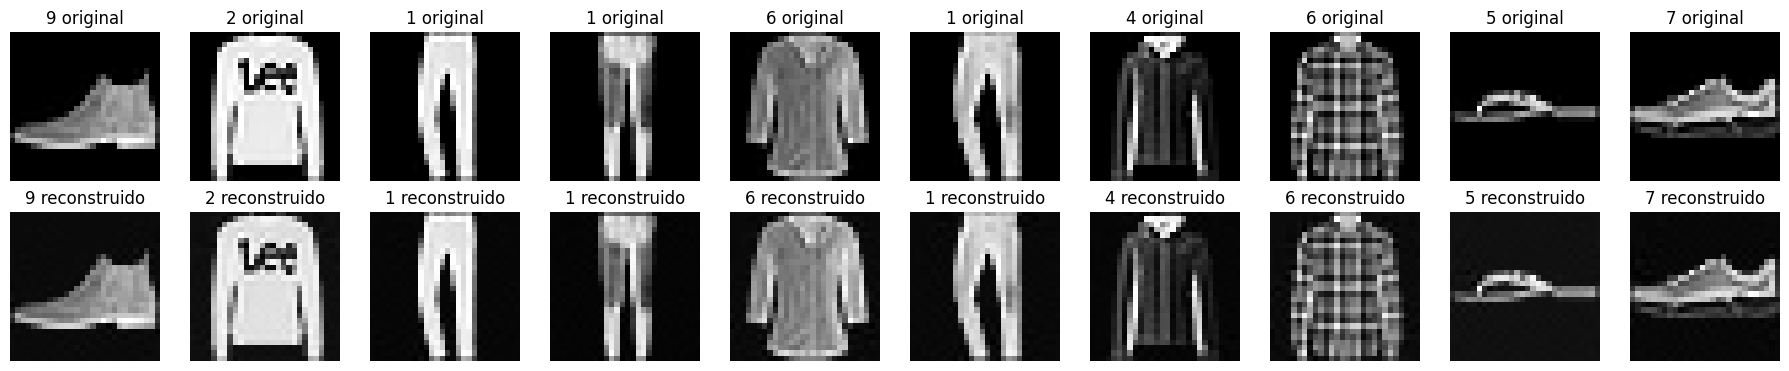

In [87]:
ncols = 10
print(X_test.shape)
Z_test = pca.transform(X_test[:ncols])  # Obtenemos Z proyectando las primeras imagenes de X con la W calculada previamente
hX_test = pca.inverse_transform(Z_test) # Obtenemos la reconstruccion hX
# Dibujamos. La primera fila son las imagenes originales. La segunda las reconstrucciones
fig, axs = plt.subplots(
    nrows=2, ncols=10, figsize=(18, 18 * 2 / ncols), constrained_layout=True
)
for i in range(ncols):
    ax = axs.flat[i]
    ax.set_axis_off()
    ax.set_title(f"{y_test[i]} original")
    ax.imshow(X_test[i, :].reshape((28, 28)), cmap=plt.cm.gray, interpolation="none")# muestra las 10 primeras imagenes originales
    ax = axs.flat[ncols + i]
    ax.set_axis_off()
    ax.set_title(f"{y_test[i]} reconstruido")
    ax.imshow(hX_test[i, :].reshape((28, 28)), cmap=plt.cm.gray, interpolation="none")# muestra las 10 ultimas

In [88]:
from sklearn.linear_model import LogisticRegression

max_K = np.min(X_train.shape)
pca = PCA(n_components=max_K).fit(X_train)
Z_train = pca.transform(X_train)
Z_test = pca.transform(X_test)
Ks = np.array([100, 200, 300, 400, 500, 600, 700, max_K])
acc_train = np.empty_like(Ks, dtype=float)
acc_test = np.empty_like(Ks, dtype=float)
for i, K in enumerate(Ks):
    clf = LogisticRegression(C=0.1, max_iter=600).fit(Z_train[:, :K], y_train)
    acc_train[i] = clf.score(Z_train[:, :K], y_train)
    acc_test[i] = clf.score(Z_test[:, :K], y_test)
plt.figure(figsize=(9, 2.5))
plt.grid(True)
plt.plot(Ks, 100.0 * acc_train, "+-b", Ks, 100.0 * acc_test, "x:m")

# En efecto, la regresión logística supera ligeramente el 84% de precisión en el test con K >= 200

KeyboardInterrupt: 

<br>


# CIFAR-10

In [90]:
import numpy as np; import datasets
ds = datasets.load_dataset("uoft-cs/cifar10").with_format("numpy"); ds

DatasetDict({
    train: Dataset({
        features: ['img', 'label'],
        num_rows: 50000
    })
    test: Dataset({
        features: ['img', 'label'],
        num_rows: 10000
    })
})

In [91]:
train0 = ds['train'][0]
train0['img'].shape, train0['img'].dtype, train0['label']

((32, 32, 3), dtype('uint8'), np.int64(0))

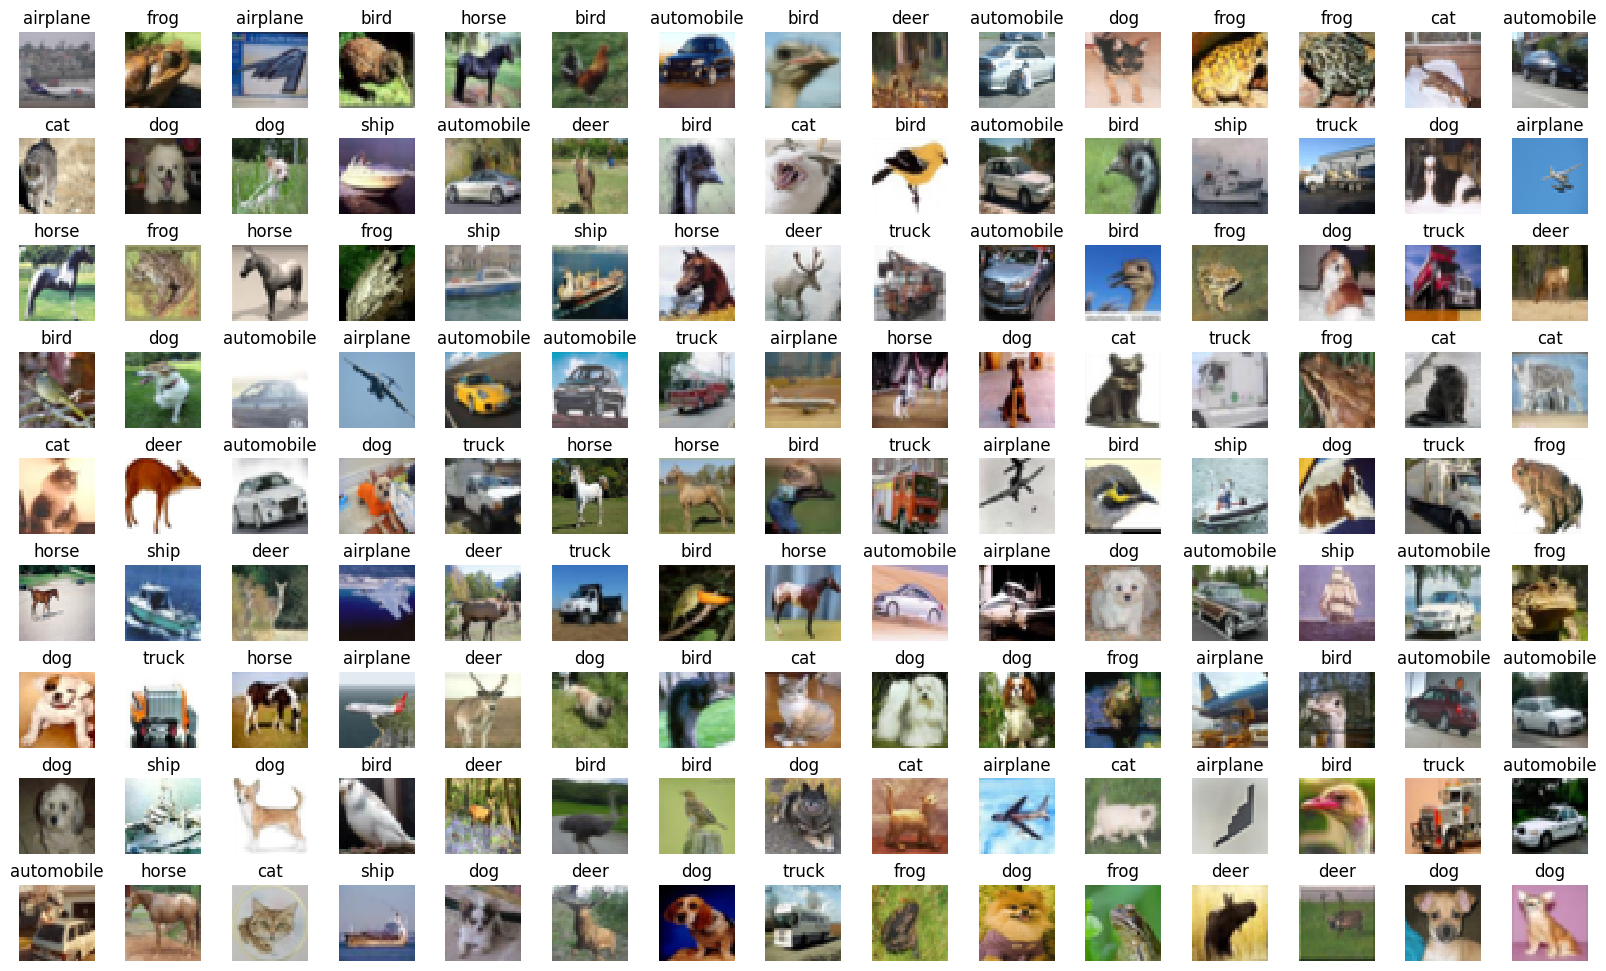

In [92]:
import matplotlib.pyplot as plt

nrows = 9
ncols = 15
N = nrows * ncols
labels = (
    "airplane",
    "automobile",
    "bird",
    "cat",
    "deer",
    "dog",
    "frog",
    "horse",
    "ship",
    "truck",
)
_, axs = plt.subplots(
    nrows=nrows, ncols=ncols, figsize=(16, 16 * nrows / ncols), constrained_layout=True
)
for ax, x, y in zip(axs.flat, ds["train"][:N]["img"], ds["train"][:N]["label"]):
    ax.set_axis_off()
    ax.imshow(x, cmap=plt.cm.gray_r, interpolation="none")
    ax.set_title(labels[y])

In [93]:
# diferencias de CIFAR-10 con respecto al resto de datasets
#   las imagenes se llaman 'img' 
#   el reshape no funciona, al ser 32x32*3, en vez de 28*28

X_train = ds['train'][:]['img'].astype(np.float32).reshape(-1, 32*32*3) / 255.
y_train = ds['train'][:]['label'].astype(np.uint8)
X_test = ds['test'][:]['img'].astype(np.float32).reshape(-1, 32*32*3) / 255.
y_test = ds['test'][:]['label'].astype(np.uint8)

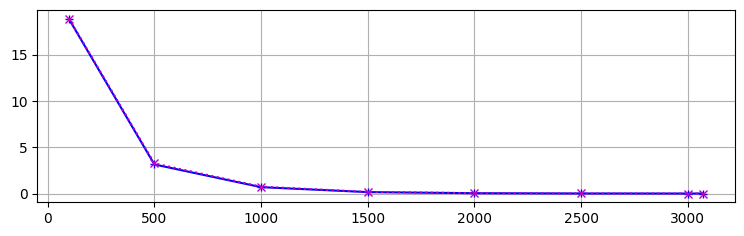

In [94]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

max_K = np.min(X_train.shape)
pca = PCA(n_components=max_K).fit(X_train)
Z_train = pca.transform(X_train)
Z_test = pca.transform(X_test)
Ks = np.array([100, 500, 1000, 1500, 2000, 2500, 3000, max_K])
L_train = np.empty_like(Ks, dtype=float)
L_test = np.empty_like(Ks, dtype=float)
for i, K in enumerate(Ks):
    Z_train_K = Z_train.copy()
    Z_train_K[:, K:] = 0.0
    hX_train = pca.inverse_transform(Z_train_K)
    L_train[i] = np.square(X_train - hX_train).sum(axis=1).mean()
    Z_test_K = Z_test.copy()
    Z_test_K[:, K:] = 0.0
    hX_test = pca.inverse_transform(Z_test_K)
    L_test[i] = np.square(X_test - hX_test).sum(axis=1).mean()
plt.figure(figsize=(9, 2.5))
plt.grid(True)
plt.plot(Ks, L_train, "+-b", Ks, L_test, "x:m")

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [0.042793036..1.0307028].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.041226298..0.9701065].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.00031095743..1.0011871].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.016931474..0.89293617].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.0353117..0.8343903].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.04657346..0.997305].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range 

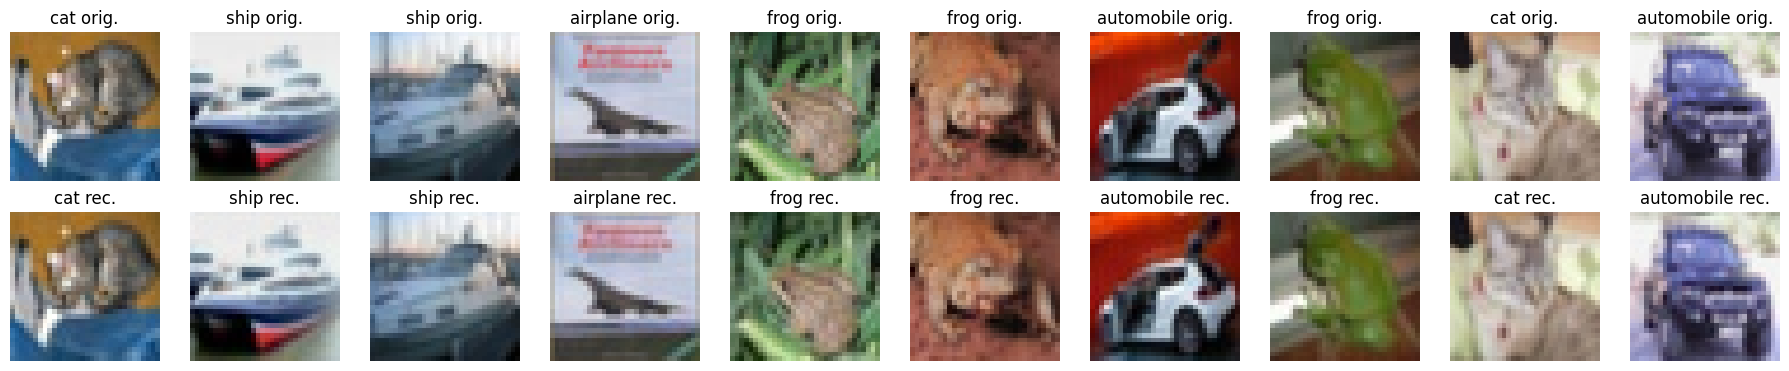

In [95]:
K = 1000
pca = PCA(n_components=K).fit(X_train)
ncols = 10
Z_test = pca.transform(X_test[:ncols])
hX_test = pca.inverse_transform(Z_test)
fig, axs = plt.subplots(
    nrows=2, ncols=ncols, figsize=(18, 18 * 2 / ncols), constrained_layout=True
)
for i in range(ncols):
    ax = axs.flat[i]
    ax.set_axis_off()
    ax.set_title(f"{labels[y_test[i]]} orig.")
    ax.imshow(X_test[i, :].reshape((32, 32, 3)), cmap=plt.cm.gray, interpolation="none")
    ax = axs.flat[ncols + i]
    ax.set_axis_off()
    ax.set_title(f"{labels[y_test[i]]} rec.")
    ax.imshow(
        hX_test[i, :].reshape((32, 32, 3)), cmap=plt.cm.gray, interpolation="none"
    )

In [100]:
from sklearn.linear_model import LogisticRegression

max_K = np.min(X_train.shape)
pca = PCA(n_components=max_K).fit(X_train)
Z_train = pca.transform(X_train)
Z_test = pca.transform(X_test)
Ks = np.array([100, 200, 500, 1000, 2000, max_K])
acc_train = np.empty_like(Ks, dtype=float)
acc_test = np.empty_like(Ks, dtype=float)
for i, K in enumerate(Ks):
    clf = LogisticRegression(C=0.05, max_iter=200).fit(Z_train[:, :K], y_train)
    acc_train[i] = clf.score(Z_train[:, :K], y_train)
    acc_test[i] = clf.score(Z_test[:, :K], y_test)
plt.figure(figsize=(9, 2.5))
plt.grid(True)
plt.plot(Ks, 100.0 * acc_train, "+-b", Ks, 100.0 * acc_test, "x:m")

/home/adria/Documentos/GitHub/University/3rd_Year/PER/env/lib/python3.14/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 200 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=200).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


KeyboardInterrupt: 

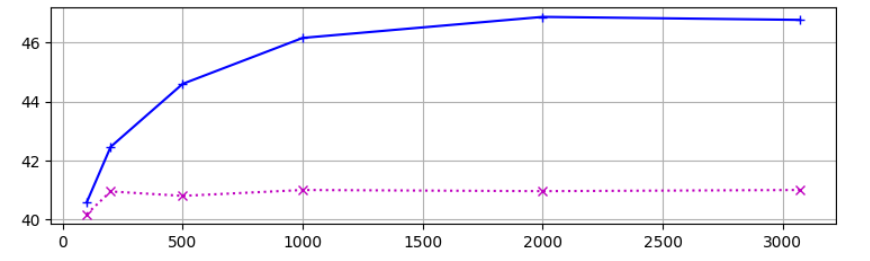